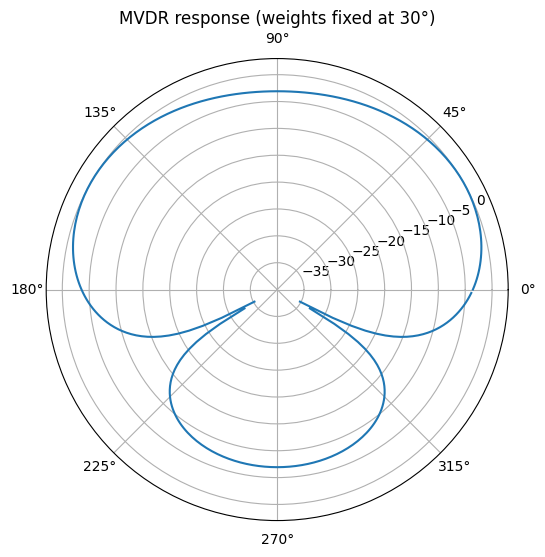

Desired look-direction  : 30°
Peak beam response @    : 30.0°


In [ ]:
#This is keeping the steering vector fixed and the delay vector moving
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1.  Steering-vector utilities (unchanged)
# ------------------------------------------------------------------
def create_steering_vector(freq_hz, angle_deg, mic_pos, c=343.0):
    θ = np.deg2rad(angle_deg)
    λ = c / freq_hz
    return np.exp(-1j * 2 * np.pi * mic_pos * np.sin(θ) / λ)

# ------------------------------------------------------------------
# 2.  Covariance estimation  (short & sweet for single-tone example)
# ------------------------------------------------------------------
def estimate_covariance(X):
    """
    X shape:  (M, T)  – M microphones, T time samples
    """
    return (X @ X.conj().T) / X.shape[1]

# ------------------------------------------------------------------
# 3.  One-shot MVDR weight design
# ------------------------------------------------------------------
def mvdr_weights(R, a):
    """
    R : (M×M) covariance
    a : (M,)   steering vector for *look* direction
    """
    δ = 1e-6 * np.trace(R) / R.shape[0]       # diagonal loading
    R_inv = np.linalg.inv(R + δ * np.eye(R.shape[0]))
    w = R_inv @ a
    return w / (a.conj().T @ R_inv @ a)

# ------------------------------------------------------------------
# 4.  Simulate array data (same as before, but kept minimal)
# ------------------------------------------------------------------
fs, dur, f0 = 44_100, 1.0, 2_000          # 2 kHz tone
c, M, d      = 343.0, 8, 0.02             # 8 mics, 2 cm spacing
mic_pos      = np.arange(M) * d
t            = np.linspace(0, dur, int(fs*dur), endpoint=False)
x0           = np.sin(2*np.pi*f0*t)                      # clean tone
noise        = 0.5*np.random.randn(*x0.shape)            # white noise
x_clean      = x0 + noise

# apply *true* delays for a real source at 30°
θ_true = 30
delay_sec = mic_pos * np.sin(np.deg2rad(θ_true)) / c
X = np.vstack([np.roll(x_clean, int(round(τ*fs)))           # shape (M, T)
               for τ in delay_sec])

# ------------------------------------------------------------------
# 5.  Design MVDR weights for the look direction (30°)
# ------------------------------------------------------------------
R = estimate_covariance(X)                                 # (M×M)
a_look = create_steering_vector(f0, θ_true, mic_pos)       # (M,)
w = mvdr_weights(R, a_look)                                # (M,)

# ------------------------------------------------------------------
# 6.  Evaluate & plot beampattern
# ------------------------------------------------------------------
angles = np.arange(0, 360)
pattern = []

for θ in angles:
    a_scan = create_steering_vector(f0, θ, mic_pos)
    pattern.append(20*np.log10(np.abs(w.conj().T @ a_scan)))

pattern = np.array(pattern)
pattern = pattern - pattern.max()    # normalize so main-lobe is 0 dB

#pattern = np.array(pattern) - pattern.max()   # normalize 0 dB at main lobe

plt.figure(figsize=(8,6))
plt.polar(np.deg2rad(angles), pattern)
plt.title("MVDR response (weights fixed at 30°)")
plt.ylim(-40, 3)
plt.grid(True)
plt.show()

print(f"Desired look-direction  : {θ_true}°")
print(f"Peak beam response @    : {angles[np.argmax(pattern)]:.1f}°")


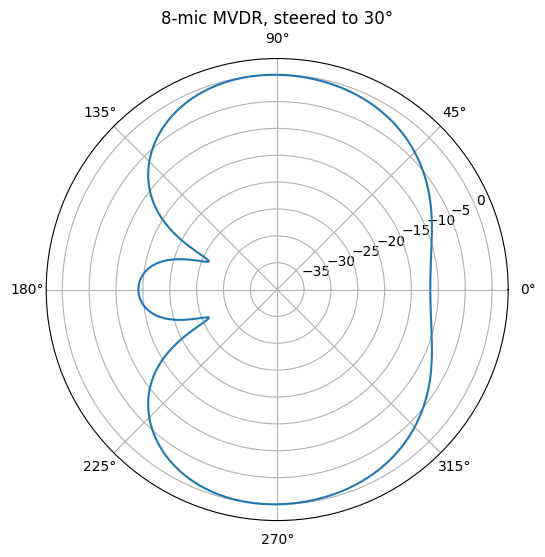

In [3]:
# --- parameters ---------------------------------------------------
c, M, d = 343.0, 8, 0.02          # mics & geometry
fs, f0  = 44_100, 2_000           # sample rate & tone
dur     = 2.0                     # seconds
θ_true  = 30                      # desired look‐direction (deg)

# --- steering vector (broadside = 0°) -----------------------------
def steering_vec(freq, theta_deg, x_pos, c=343.0):
    θ = np.deg2rad(theta_deg)
    λ = c / freq
    return np.exp(-1j * 2*np.pi * x_pos * np.cos(θ) / λ)  # <-- cos!

# --- simulate multichannel data ----------------------------------
mic_pos = np.arange(M) * d
t       = np.arange(int(dur*fs)) / fs
src     = np.sin(2*np.pi*f0*t) + 0.1*np.random.randn(t.size)
delays  = mic_pos * np.cos(np.deg2rad(θ_true)) / c
X       = np.vstack([np.roll(src, int(round(τ*fs))) for τ in delays])

# --- covariance (100 snapshots) ----------------------------------
snap = 2048
n    = X.shape[1] // snap
R    = sum(X[:,i*snap:(i+1)*snap] @ X[:,i*snap:(i+1)*snap].conj().T
           for i in range(n)) / (n*snap)
R   += 1e-3 * np.trace(R)/M * np.eye(M)         # diagonal loading

# --- MVDR weights -------------------------------------------------
a_look = steering_vec(f0, θ_true, mic_pos)
w      = np.linalg.inv(R) @ a_look
w     /= a_look.conj().T @ np.linalg.inv(R) @ a_look

# --- beampattern scan --------------------------------------------
angles  = np.arange(0, 360)
pat_db  = 20*np.log10(np.abs([w.conj().T @ steering_vec(f0, th, mic_pos)
                              for th in angles]))
pat_db -= pat_db.max()

plt.figure(figsize=(6,6))
plt.subplot(111, projection='polar').plot(np.deg2rad(angles), pat_db)
plt.title("8-mic MVDR, steered to 30°"); plt.ylim(-40, 3); plt.grid(True)
plt.show()


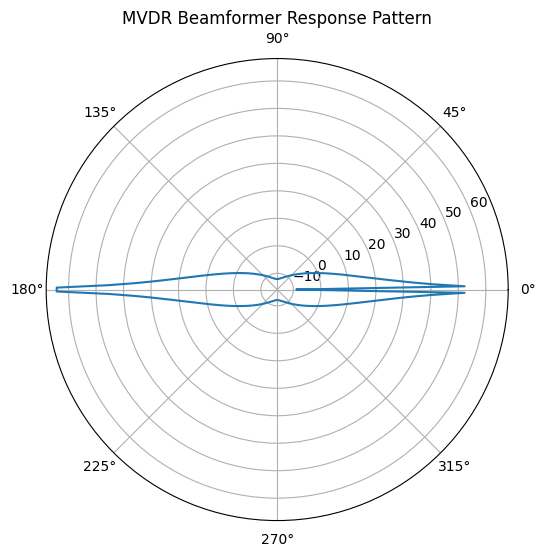

Target angle: 30°
Maximum response at: 179.5°
Response at target angle: -4.2 dB
Maximum response: 64.3 dB


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import stft, istft
import soundfile as sf
#what im doing wrong: only one delay, delay needs to change with every angle. 
#multiple steering vectors for each angle, steering vector stays the same and delay has to change

def calculate_snr(signal, noise):
    """
    Calculate Signal-to-Noise Ratio in dB.
    
    :param signal: Signal array
    :param noise: Noise array
    :return: SNR in dB
    """
    signal_power = np.mean(signal ** 2)
    noise_power = np.mean(noise ** 2)
    snr = 10 * np.log10(signal_power / noise_power)
    return snr

def calculate_beamformer_snr(input_snr, beamformed_signal, original_signal, noise):
    """
    Calculate the SNR improvement from beamforming.
    
    :param input_snr: Input SNR in dB
    :param beamformed_signal: Beamformed output signal
    :param original_signal: Original signal
    :param noise: Noise signal
    :return: Output SNR and SNR improvement in dB
    """
    # Calculate output SNR
    signal_power = np.mean(beamformed_signal ** 2)
    noise_power = np.mean(noise ** 2)
    output_snr = 10 * np.log10(signal_power / noise_power)
    
    # Calculate SNR improvement
    snr_improvement = output_snr - input_snr
    
    return output_snr, snr_improvement

def make_mono_audio(frequency: int, write_file: bool = False, duration: float = 1.0, sampling_rate: int = 44100, snr_db: float = 0):
    """
    Generate a mono sine wave audio signal with controlled SNR.

    :param frequency: Frequency of the sine wave in Hz.
    :param write_file: If True, saves the generated audio as a WAV file.
    :param duration: Duration of the generated sine wave in seconds (default: 1.0s).
    :param sampling_rate: Sampling rate in Hz (default: 44100 Hz).
    :param snr_db: Desired SNR in dB (default: 0 dB).
    :return: Tuple of (signal, noise, clean_signal)
    """
    t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)
    clean_signal = np.sin(2 * np.pi * frequency * t)
    
    # Generate noise with controlled power
    signal_power = np.mean(clean_signal ** 2)
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), len(clean_signal))
    
    # Combine signal and noise
    result = clean_signal + noise

    if write_file:
        write("updated_sin1k.wav", sampling_rate, result.astype(np.float32))

    return result, noise, clean_signal

def create_delay_vector(speed_of_sound, angle_rad, num_mics, mic_separation):
    """
    Create a delay vector for microphone array beamforming.

    :param speed_of_sound: Speed of sound in m/s.
    :param angle_rad: Steering angle in radians.
    :param num_mics: Number of microphones in the array.
    :param mic_separation: Distance between adjacent microphones in meters.
    :return: Delay vector for each microphone.
    """
    mic_positions = np.arange(num_mics) * mic_separation
    delay_vector = -mic_positions * np.sin(angle_rad) / speed_of_sound
    return delay_vector

def set_steering_vector(delay_vector, signal_length, fs):
    """
    Generate a steering vector for phase shifting.

    :param delay_vector: Delays for each microphone.
    :param signal_length: Length of the mono audio signal.
    :param fs: Sampling frequency in Hz.
    :return: Steering vector for phase shifting.
    """
    freqs = np.fft.rfftfreq(signal_length, d=1/fs)
    steering_vector = np.exp(-1j * 2 * np.pi * freqs[:, np.newaxis] * delay_vector)
    return steering_vector

def delay_across_channels_py_freq(mono_audio, steering_angle, num_mics, mic_separation, fs, speed_of_sound=343.0):
    """
    Delays a mono audio signal across multiple microphones in the frequency domain.

    :param mono_audio: Input mono audio signal (NumPy array).
    :param steering_angle: Desired steering angle in degrees.
    :param num_mics: Number of microphones in the array.
    :param mic_separation: Distance between adjacent microphones in meters.
    :param fs: Sampling frequency in Hz.
    :param speed_of_sound: Speed of sound in m/s (default: 343 m/s).
    :return: Delayed multi-channel audio signal (NumPy array).
    """
    if mono_audio.ndim == 1:
        mono_audio = mono_audio[:, np.newaxis]  # Ensure column vector
    if num_mics <= 0:
        raise ValueError("Number of microphones must be greater than 0!")

    steering_angle = -steering_angle  # Reverse angle for correct steering calculations

    # FFT of the mono audio
    mono_audio_f = np.fft.rfft(mono_audio, axis=0)

    # Create an empty ydelay matrix
    ydelay = np.tile(mono_audio_f, (1, num_mics))  # Replicate signal across microphones

    # Convert angle to radians
    angle_rad = np.radians(steering_angle)

    # Compute delays and steering vector
    delay = create_delay_vector(speed_of_sound, angle_rad, num_mics, mic_separation)
    steering_vector = set_steering_vector(delay, len(mono_audio), fs)

    # Apply phase shifts (fixing broadcasting issue)
    ydelay *= steering_vector  # No transposition needed

    # Inverse FFT to get the time-domain signal
    result = np.fft.irfft(ydelay, axis=0)

    return result

def create_steering_vector(freq, angle_deg, mic_positions, c=343.0):
    """
    Create a steering vector for a single frequency.
    
    :param freq: Frequency in Hz
    :param angle_deg: Steering angle in degrees
    :param mic_positions: Array of microphone positions
    :param c: Speed of sound in m/s
    :return: Steering vector
    """
    angle_rad = np.deg2rad(angle_deg)
    wavelength = c / freq
    return np.exp(-1j * 2 * np.pi * mic_positions * np.sin(angle_rad) / wavelength)

def mvdr_beamformer(signal, target_angle, mic_positions, freq, c=343.0):
    """
    Simple MVDR beamformer for a single frequency.
    
    :param signal: Input signal array (M x T)
    :param target_angle: Target angle in degrees
    :param mic_positions: Array of microphone positions
    :param freq: Signal frequency in Hz
    :param c: Speed of sound in m/s
    :return: Beamformed signal
    """
    M = len(mic_positions)
    
    # Create steering vector
    a = create_steering_vector(freq, target_angle, mic_positions, c)
    
    # Estimate covariance matrix
    R = np.zeros((M, M), dtype=np.complex128)
    for t in range(signal.shape[1]):
        x = signal[:, t:t+1]
        #R += x @ x.conj().T
        R += x.conj().T @ x
    R /= signal.shape[1]
    
    # Add diagonal loading
    R += 1e-6 * np.trace(R) * np.eye(M) / M
    
    # Compute MVDR weights
    R_inv = np.linalg.inv(R)
    w = R_inv @ a
    w /= (a.conj().T @ R_inv @ a)
    
    # Apply weights
#    return w.conj().T @ signal
    return signal@w.conj().T

def estimate_covariance_matrix(X, num_snapshots=50):
    """
    Estimate the spatial covariance matrix using multiple snapshots.
    
    :param X: STFT of the signal, shape (M, F, T)
    :param num_snapshots: Number of snapshots to use
    :return: Covariance matrix of shape (F, M, M)
    """
    M, F, T = X.shape
    R = np.zeros((F, M, M), dtype=np.complex128)
    
    # Use multiple snapshots for better estimation
    for f in range(F):
        # Select random snapshots
        snapshots = X[:, f, :num_snapshots]
        # Compute covariance matrix
        R[f] = np.mean(snapshots @ snapshots.conj().T, axis=1)
        
        # Add diagonal loading for robustness
        delta = 1e-3 * np.trace(R[f]) / M
        R[f] += delta * np.eye(M)
    
    return R

def compute_mvdr_weights(steering_vector, R):
    """
    Compute MVDR beamforming weights using proper matrix inversion.
    
    :param steering_vector: Steering vector of shape (F, M)
    :param R: Covariance matrix of shape (F, M, M)
    :return: Beamforming weights of shape (F, M)
    """
    F, M = steering_vector.shape
    w = np.empty_like(steering_vector, dtype=np.complex128)
    
    for f in range(F):
        # Compute inverse of covariance matrix
        R_inv = np.linalg.inv(R[f])
        # Compute MVDR weights
        w[f] = R_inv @ steering_vector[f]
        # Normalize
        w[f] /= (steering_vector[f].conj().T @ R_inv @ steering_vector[f])
    
    return w

# ------------------------ Array & signal parameters ------------------------
freq = 2000  # 1 kHz test signal
c = 343.0    # Speed of sound
M = 8        # Number of microphones
d = 0.02     # 4 cm spacing
fs = 44100   # Sampling rate
duration = 1.0  # Signal duration

# Create microphone array
mic_positions = np.arange(M) * d

# Generate test signal
t = np.linspace(0, duration, int(fs * duration))
signal = np.sin(2 * np.pi * freq * t)
#signal = signal.reshape(1, -1)  # Single channel

noise = np.random.normal(0, 1, signal.shape)
signal += noise
#signal = signal.reshape(-1)  # Flatten to 1D


signal = np.tile(signal, (M, 1))  # Replicate across microphones

#print(np.shape(signal))
# Add noise

# Add some phase delay to simulate direction
target_angle = 30  # degrees
delay = mic_positions * np.sin(np.deg2rad(target_angle)) / c
delay_samples = (delay * fs).astype(int)
for m in range(M):
    signal[m] = np.roll(signal[m], delay_samples[m])


signal = signal.T  # Transpose to shape (T, M)

# Test different angles
angles = np.linspace(0, 360, 360)
responses = []

for angle in angles:
    # Apply MVDR beamformer
    output = mvdr_beamformer(signal, angle, mic_positions, freq)
    # Calculate response power
    response = np.mean(np.abs(output) ** 2)
    responses.append(20 * np.log10(response))

# Plot results
plt.figure(figsize=(10, 6))
plt.polar(np.deg2rad(angles), responses)
plt.title('MVDR Beamformer Response Pattern')
plt.grid(True)
plt.show()

# Print target angle and maximum response
max_idx = np.argmax(responses)
print(f"Target angle: {target_angle}°")
print(f"Maximum response at: {angles[max_idx]:.1f}°")
print(f"Response at target angle: {responses[int(target_angle)]:.1f} dB")
print(f"Maximum response: {np.max(responses):.1f} dB")

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.io import wavfile
# from scipy.signal import stft, istft
# import soundfile as sf
# #what im doing wrong: only one delay, delay needs to change with every angle. 
# #multiple steering vectors for each angle, steering vector stays the same and delay has to change

# def calculate_snr(signal, noise):
#     """
#     Calculate Signal-to-Noise Ratio in dB.
    
#     :param signal: Signal array
#     :param noise: Noise array
#     :return: SNR in dB
#     """
#     signal_power = np.mean(signal ** 2)
#     noise_power = np.mean(noise ** 2)
#     snr = 10 * np.log10(signal_power / noise_power)
#     return snr

# def calculate_beamformer_snr(input_snr, beamformed_signal, original_signal, noise):
#     """
#     Calculate the SNR improvement from beamforming.
    
#     :param input_snr: Input SNR in dB
#     :param beamformed_signal: Beamformed output signal
#     :param original_signal: Original signal
#     :param noise: Noise signal
#     :return: Output SNR and SNR improvement in dB
#     """
#     # Calculate output SNR
#     signal_power = np.mean(beamformed_signal ** 2)
#     noise_power = np.mean(noise ** 2)
#     output_snr = 10 * np.log10(signal_power / noise_power)
    
#     # Calculate SNR improvement
#     snr_improvement = output_snr - input_snr
    
#     return output_snr, snr_improvement

# def make_mono_audio(frequency: int, write_file: bool = False, duration: float = 1.0, sampling_rate: int = 44100, snr_db: float = 0):
#     """
#     Generate a mono sine wave audio signal with controlled SNR.

#     :param frequency: Frequency of the sine wave in Hz.
#     :param write_file: If True, saves the generated audio as a WAV file.
#     :param duration: Duration of the generated sine wave in seconds (default: 1.0s).
#     :param sampling_rate: Sampling rate in Hz (default: 44100 Hz).
#     :param snr_db: Desired SNR in dB (default: 0 dB).
#     :return: Tuple of (signal, noise, clean_signal)
#     """
#     t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)
#     clean_signal = np.sin(2 * np.pi * frequency * t)
    
#     # Generate noise with controlled power
#     signal_power = np.mean(clean_signal ** 2)
#     noise_power = signal_power / (10 ** (snr_db / 10))
#     noise = np.random.normal(0, np.sqrt(noise_power), len(clean_signal))
    
#     # Combine signal and noise
#     result = clean_signal + noise

#     if write_file:
#         write("updated_sin1k.wav", sampling_rate, result.astype(np.float32))

#     return result, noise, clean_signal

# def create_delay_vector(speed_of_sound, angle_rad, num_mics, mic_separation):
#     """
#     Create a delay vector for microphone array beamforming.

#     :param speed_of_sound: Speed of sound in m/s.
#     :param angle_rad: Steering angle in radians.
#     :param num_mics: Number of microphones in the array.
#     :param mic_separation: Distance between adjacent microphones in meters.
#     :return: Delay vector for each microphone.
#     """
#     mic_positions = np.arange(num_mics) * mic_separation
#     delay_vector = -mic_positions * np.sin(angle_rad) / speed_of_sound
#     return delay_vector

# def set_steering_vector(delay_vector, signal_length, fs):
#     """
#     Generate a steering vector for phase shifting.

#     :param delay_vector: Delays for each microphone.
#     :param signal_length: Length of the mono audio signal.
#     :param fs: Sampling frequency in Hz.
#     :return: Steering vector for phase shifting.
#     """
#     freqs = np.fft.rfftfreq(signal_length, d=1/fs)
#     steering_vector = np.exp(-1j * 2 * np.pi * freqs[:, np.newaxis] * delay_vector)
#     return steering_vector

# def delay_across_channels_py_freq(mono_audio, steering_angle, num_mics, mic_separation, fs, speed_of_sound=343.0):
#     """
#     Delays a mono audio signal across multiple microphones in the frequency domain.

#     :param mono_audio: Input mono audio signal (NumPy array).
#     :param steering_angle: Desired steering angle in degrees.
#     :param num_mics: Number of microphones in the array.
#     :param mic_separation: Distance between adjacent microphones in meters.
#     :param fs: Sampling frequency in Hz.
#     :param speed_of_sound: Speed of sound in m/s (default: 343 m/s).
#     :return: Delayed multi-channel audio signal (NumPy array).
#     """
#     if mono_audio.ndim == 1:
#         mono_audio = mono_audio[:, np.newaxis]  # Ensure column vector
#     if num_mics <= 0:
#         raise ValueError("Number of microphones must be greater than 0!")

#     steering_angle = -steering_angle  # Reverse angle for correct steering calculations

#     # FFT of the mono audio
#     mono_audio_f = np.fft.rfft(mono_audio, axis=0)

#     # Create an empty ydelay matrix
#     ydelay = np.tile(mono_audio_f, (1, num_mics))  # Replicate signal across microphones

#     # Convert angle to radians
#     angle_rad = np.radians(steering_angle)

#     # Compute delays and steering vector
#     delay = create_delay_vector(speed_of_sound, angle_rad, num_mics, mic_separation)
#     steering_vector = set_steering_vector(delay, len(mono_audio), fs)

#     # Apply phase shifts (fixing broadcasting issue)
#     ydelay *= steering_vector  # No transposition needed

#     # Inverse FFT to get the time-domain signal
#     result = np.fft.irfft(ydelay, axis=0)

#     return result

# def create_steering_vector(freq, angle_deg, mic_positions, c=343.0):
#     """
#     Create a steering vector for a single frequency.
    
#     :param freq: Frequency in Hz
#     :param angle_deg: Steering angle in degrees
#     :param mic_positions: Array of microphone positions
#     :param c: Speed of sound in m/s
#     :return: Steering vector
#     """
#     angle_rad = np.deg2rad(angle_deg)
#     wavelength = c / freq
#     return np.exp(-1j * 2 * np.pi * mic_positions * np.sin(angle_rad) / wavelength)

# def mvdr_beamformer(signal, target_angle, mic_positions, freq, c=343.0):
#     """
#     Simple MVDR beamformer for a single frequency.
    
#     :param signal: Input signal array (M x T)
#     :param target_angle: Target angle in degrees
#     :param mic_positions: Array of microphone positions
#     :param freq: Signal frequency in Hz
#     :param c: Speed of sound in m/s
#     :return: Beamformed signal
#     """
#     M = len(mic_positions)
    
#     # Create steering vector
#     a = create_steering_vector(freq, target_angle, mic_positions, c)
    
#     # Estimate covariance matrix
#     R = np.zeros((M, M), dtype=np.complex128)
#     for t in range(signal.shape[1]):
#         x = signal[:, t:t+1]
#         #R += x @ x.conj().T
#         R += x.conj().T @ x
#     R /= signal.shape[1]
    
#     # Add diagonal loading
#     R += 1e-6 * np.trace(R) * np.eye(M) / M
    
#     # Compute MVDR weights
#     R_inv = np.linalg.inv(R)
#     w = R_inv @ a
#     w /= (a.conj().T @ R_inv @ a)
    
#     # Apply weights
# #    return w.conj().T @ signal
#     return signal@w.conj().T

# def estimate_covariance_matrix(X, num_snapshots=50):
#     """
#     Estimate the spatial covariance matrix using multiple snapshots.
    
#     :param X: STFT of the signal, shape (M, F, T)
#     :param num_snapshots: Number of snapshots to use
#     :return: Covariance matrix of shape (F, M, M)
#     """
#     M, F, T = X.shape
#     R = np.zeros((F, M, M), dtype=np.complex128)
    
#     # Use multiple snapshots for better estimation
#     for f in range(F):
#         # Select random snapshots
#         snapshots = X[:, f, :num_snapshots]
#         # Compute covariance matrix
#         R[f] = np.mean(snapshots @ snapshots.conj().T, axis=1)
        
#         # Add diagonal loading for robustness
#         delta = 1e-3 * np.trace(R[f]) / M
#         R[f] += delta * np.eye(M)
    
#     return R

# def compute_mvdr_weights(steering_vector, R):
#     """
#     Compute MVDR beamforming weights using proper matrix inversion.
    
#     :param steering_vector: Steering vector of shape (F, M)
#     :param R: Covariance matrix of shape (F, M, M)
#     :return: Beamforming weights of shape (F, M)
#     """
#     F, M = steering_vector.shape
#     w = np.empty_like(steering_vector, dtype=np.complex128)
    
#     for f in range(F):
#         # Compute inverse of covariance matrix
#         R_inv = np.linalg.inv(R[f])
#         # Compute MVDR weights
#         w[f] = R_inv @ steering_vector[f]
#         # Normalize
#         w[f] /= (steering_vector[f].conj().T @ R_inv @ steering_vector[f])
    
#     return w

# # ------------------------ Array & signal parameters ------------------------
# freq = 2000  # 1 kHz test signal
# c = 343.0    # Speed of sound
# M = 8        # Number of microphones
# d = 0.02     # 4 cm spacing
# fs = 44100   # Sampling rate
# duration = 1.0  # Signal duration

# # Create microphone array
# mic_positions = np.arange(M) * d

# # Generate test signal
# t = np.linspace(0, duration, int(fs * duration))
# signal = np.sin(2 * np.pi * freq * t)
# #signal = signal.reshape(1, -1)  # Single channel

# noise = np.random.normal(0, 1, signal.shape)
# signal += noise
# #signal = signal.reshape(-1)  # Flatten to 1D


# signal = np.tile(signal, (M, 1))  # Replicate across microphones

# #print(np.shape(signal))
# # Add noise

# # Add some phase delay to simulate direction
# target_angle = 30  # degrees
# delay = mic_positions * np.sin(np.deg2rad(target_angle)) / c
# delay_samples = (delay * fs).astype(int)
# for m in range(M):
#     signal[m] = np.roll(signal[m], delay_samples[m])


# signal = signal.T  # Transpose to shape (T, M)

# # Test different angles
# angles = np.linspace(0, 360, 360)
# responses = []

# for angle in angles:
#     # Apply MVDR beamformer
#     output = mvdr_beamformer(signal, angle, mic_positions, freq)
#     # Calculate response power
#     response = np.mean(np.abs(output) ** 2)
#     responses.append(20 * np.log10(response))

# # Plot results
# plt.figure(figsize=(10, 6))
# plt.polar(np.deg2rad(angles), responses)
# plt.title('MVDR Beamformer Response Pattern')
# plt.grid(True)
# plt.show()

# # Print target angle and maximum response
# max_idx = np.argmax(responses)
# print(f"Target angle: {target_angle}°")
# print(f"Maximum response at: {angles[max_idx]:.1f}°")
# print(f"Response at target angle: {responses[int(target_angle)]:.1f} dB")
# print(f"Maximum response: {np.max(responses):.1f} dB")

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1.  Steering-vector utilities (unchanged)
# ------------------------------------------------------------------
def create_steering_vector(freq_hz, angle_deg, mic_pos, c=343.0):
    θ = np.deg2rad(angle_deg)
    λ = c / freq_hz
    return np.exp(-1j * 2 * np.pi * mic_pos * np.sin(θ) / λ)

# ------------------------------------------------------------------
# 2.  Covariance estimation  (short & sweet for single-tone example)
# ------------------------------------------------------------------
def estimate_covariance(X):
    """
    X shape:  (M, T)  – M microphones, T time samples
    """
    return (X @ X.conj().T) / X.shape[1]

# ------------------------------------------------------------------
# 3.  One-shot MVDR weight design
# ------------------------------------------------------------------
def mvdr_weights(R, a):
    """
    R : (M×M) covariance
    a : (M,)   steering vector for *look* direction
    """
    δ = 1e-6 * np.trace(R) / R.shape[0]       # diagonal loading
    R_inv = np.linalg.inv(R + δ * np.eye(R.shape[0]))
    w = R_inv @ a
    return w / (a.conj().T @ R_inv @ a)

# ------------------------------------------------------------------
# 4.  Simulate array data (same as before, but kept minimal)
# ------------------------------------------------------------------
fs, dur = 44_100, 1.0          # sampling rate and duration
c, M, d = 343.0, 8, 0.02       # 8 mics, 2 cm spacing
mic_pos = np.arange(M) * d

# Test frequencies (in Hz)
freqs = [1000, 2000, 4000]  # 1 kHz, 2 kHz, 4 kHz

# Create figure for Cartesian plot
plt.figure(figsize=(12, 8))

# Test each frequency
for f0 in freqs:
    # Generate clean tone
    t = np.linspace(0, dur, int(fs*dur), endpoint=False)
    x0 = np.sin(2*np.pi*f0*t)
    noise = 0.5*np.random.randn(*x0.shape)
    x_clean = x0 + noise

    # apply *true* delays for a real source at 0° (broadside)
    θ_true = 0
    delay_sec = mic_pos * np.sin(np.deg2rad(θ_true)) / c
    X = np.vstack([np.roll(x_clean, int(round(τ*fs)))
                   for τ in delay_sec])

    # Design MVDR weights for broadside
    R = estimate_covariance(X)
    a_look = create_steering_vector(f0, θ_true, mic_pos)
    w = mvdr_weights(R, a_look)

    # Evaluate beampattern
    angles = np.arange(-90, 91)  # -90° to +90°
    pattern = []

    for θ in angles:
        a_scan = create_steering_vector(f0, θ, mic_pos)
        pattern.append(20*np.log10(np.abs(w.conj().T @ a_scan)))

    pattern = np.array(pattern)
    pattern = pattern - pattern.max()    # normalize so main-lobe is 0 dB

    # Plot in Cartesian coordinates
    plt.plot(angles, pattern, label=f'{f0/1000:.1f} kHz')

plt.title('MVDR Beam Pattern (Broadside Steering)')
plt.xlabel('Angle (degrees)')
plt.ylabel('Normalized Response (dB)')
plt.grid(True)
plt.legend()
plt.ylim(-40, 3)
plt.xlim(-90, 90)
plt.show()

print(f"Desired look-direction: {θ_true}°")
print(f"Peak beam response @  : {angles[np.argmax(pattern)]:.1f}°")
